- <span style="color:skyblue">НАЧНЁМ С 1-Й ЧАСТИ ГРУППОВОГО ЗАДАНИЯ: ПРОВЕДЕНИЯ EDA-АНАЛИЗА И A/B-ТЕСТИРОВАНИЯ ДЛЯ ДАТАСЕТА "data_ab.csv"</span>

In [46]:
# Импортируем необходимые библиотеки
import pandas as pd
import numpy as np
import statsmodels.api as sm

import matplotlib.pyplot as plt

from scipy import stats
from scipy.stats import ttest_ind, levene

from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.proportion import proportions_ztest

--------------------------
<span style="color:white">ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ: EDA</span>

In [47]:
df = pd.read_csv('data_ab.csv')
df

,user_id,timestamp,group,landing_page,converted
0,851104,2025-01-21 22:11:48.556739,control,old_page,0
1,804228,2025-01-12 08:01:45.159739,control,old_page,0
2,661590,2025-01-11 16:55:06.154213,treatment,new_page,0
3,853541,2025-01-08 18:28:03.143765,treatment,new_page,0
4,864975,2025-01-21 01:52:26.210827,control,old_page,1
...,...,...,...,...,...
294473,751197,2025-01-03 22:28:38.630509,control,old_page,0
294474,945152,2025-01-12 00:51:57.078372,control,old_page,0
294475,734608,2025-01-22 11:45:03.439544,control,old_page,0
294476,697314,2025-01-15 01:20:28.957438,control,old_page,0



* `user_id` — уникальный идентификатор пользователя;

* `timestamp` — время посещения пользователем страницы;

* `group` — группа эксперимента, к которой был случайно отнесён пользователь:

  *   `control` — контрольная группа,
  *   `treatment` — экспериментальная группа;

* `landing_page` — версия лендинга, которую увидел пользователь:

  *   `old_page` — старая версия страницы,
  *   `new_page` — новая версия страницы;

* **`converted` — бинарный признак, показывающий, совершил ли пользователь целевое действие (целевым действием является регистрация на курс) - целевая переменная**.

In [48]:
# Посмотрим на типы данных
df.dtypes

user_id          int64
timestamp       object
group           object
landing_page    object
converted        int64
dtype: object

In [49]:
# Пропусков в данных не обнаружено
df.isna().sum()

user_id         0
timestamp       0
group           0
landing_page    0
converted       0
dtype: int64

- `Среди двух групп есть объекты, которым показывали не ту версию страницы, при этом они находились в группе другого типа`

In [50]:
badB = df[(df['group'] == 'control') & (df['landing_page'] == 'new_page')]
badA = df[(df['group'] == 'treatment') & (df['landing_page'] == 'old_page')]
print(badA.shape, badB.shape)

(1965, 5) (1928, 5)


- `Таким объектам можно просто поменять тип группы на действительный (правильный), при этом все оставшиеся характеристики будут корректны, ведь они фиксировались именно на соответствующей странице (old page / new page)`

In [51]:
df[(df['group'] == 'treatment') & (df['landing_page'] == 'old_page')] = df[(df['group'] == 'treatment') & (df['landing_page'] == 'old_page')].replace('treatment', 'control')
df[(df['group'] == 'control') & (df['landing_page'] == 'new_page')] = df[(df['group'] == 'control') & (df['landing_page'] == 'new_page')].replace('control', 'treatment')
badB = df[(df['group'] == 'control') & (df['landing_page'] == 'new_page')]
badA = df[(df['group'] == 'treatment') & (df['landing_page'] == 'old_page')]
print('После смены типа на правильный: ', badA.shape, badB.shape)

После смены типа на правильный:  (0, 5) (0, 5)


In [52]:
# Теперь размерность групп примерно одинаковая
A = df[df['group'] == 'control']
B = df[df['group'] == 'treatment']
print('Размерность всего датасета: ', df.shape)
print('Размерность контрольной и экспериментальной групп: ', A.shape, B.shape)

Размерность всего датасета:  (294478, 5)
Размерность контрольной и экспериментальной групп:  (147239, 5) (147239, 5)


In [53]:
# Исследуем количество пользователей по дням в контрольной и тестовой группе
df.timestamp = pd.DatetimeIndex(df.timestamp) # Приводим столбик к типу datetime для удобной работы

mx_date = df['timestamp'].min() # 2025-01-02
mn_date = df['timestamp'].max() # 2025-01-24
print('Максимальная дата и время: ', mx_date, '\nМинимальная дата и время: ', mn_date)

daily = df.groupby(['timestamp', 'group']).size().unstack()
daily.describe()

Максимальная дата и время:  2025-01-02 13:42:05.378582 
Минимальная дата и время:  2025-01-24 13:41:54.460509


group,control,treatment
count,147239.0,147239.0
mean,1.0,1.0
std,0.0,0.0
min,1.0,1.0
25%,1.0,1.0
50%,1.0,1.0
75%,1.0,1.0
max,1.0,1.0


<span style="color:skyblue">Эксперимент длится 22 дня, количество экспериментов в контрольной и тестовой группе сбалансированны: медианы, разброс значений и квантили практически совпадают, то есть по форме распределений обе группы (контрольная и экспериментальная) схожи</span>

- `Среди пользоваталей есть те, кто посещал страницу несколько раз. Это может быть важно, если при разных посещениях одного пользователя распределили в разные группы, иначе нарушается независимость групп`

In [54]:
duplicates = df['user_id'].value_counts()
multi_users = duplicates[duplicates > 1]
print('Доля повторяющихся пользователей в датасете: ', len(multi_users) / len(df['user_id'].unique()))

multi = df[df['user_id'].duplicated(keep=False)] # Все строки с повторяющимися id пользователей
user_groups = multi.groupby('user_id')['group'].nunique()
bad_users = user_groups[user_groups > 1] # Датасет с id пользователей и количеством групп, в которых они состоят
print('Доля пользователей состоящих в несколько группах: ', len(bad_users) / len(df['user_id'].unique()))

delete_users = df['user_id'].isin(bad_users.index)
df = df.loc[delete_users == False] # Удаляем таких пользователей из основного датасета

df = df.sort_values('timestamp') # Сортируем по времени, чтобы оставить только первые посещения
df = df.drop_duplicates(subset='user_id', keep='first') # Оставляем толькое первое посещение
duplicates = df['user_id'].value_counts() 
multi_users = duplicates[duplicates > 1] # Ещё раз проверяем, что дубликатов нет
print('Кол-во юзеров (после чистки), у которых несколько посещений: ', len(multi_users))

Доля повторяющихся пользователей в датасете:  0.013400600170690747
Доля пользователей состоящих в несколько группах:  0.006875808716240398
Кол-во юзеров (после чистки), у которых несколько посещений:  0


- `Получается, что есть примерно 2000 пользователей, которые одновременно присутствуют в двух группах. Дабы не нарушать независиомсть двух выборок, можно удалить этих пользователей, но после удаления осталось еще примерно 2000 пользователей, которые посещали сайт несколько раз, при том что были распределены только в 1 группу - для них оставляем только самую первую запись`

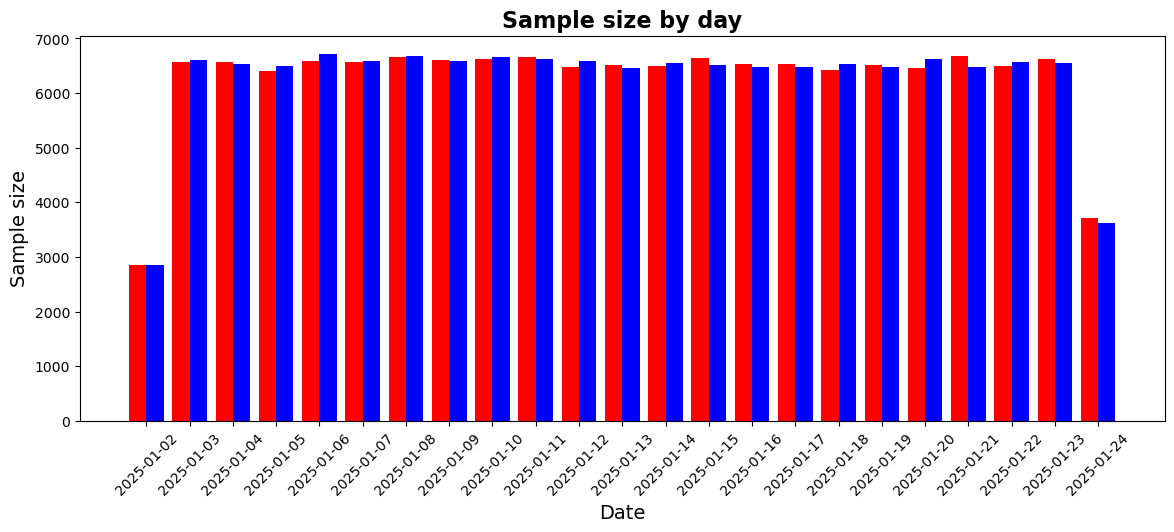

In [55]:
df_time = df.copy()
df_time['date'] = df_time['timestamp'].dt.date
df_time = df_time.groupby(['date', 'group']).size().reset_index(name='users')
pivot = df_time.pivot(index='date', columns='group', values='users')

plt.figure(figsize=(14, 5))

plt.bar([i - 0.2 for i in range(len(pivot))], pivot['control'], color='red', width=0.4)
plt.bar([i + 0.2 for i in range(len(pivot))], pivot['treatment'], color='blue', width=0.4)

plt.title('Sample size by day',  fontsize=16, fontweight='bold')
plt.xticks(range(len(pivot)), pivot.index, rotation=45)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Sample size', fontsize=14)
plt.show()

-------------------------
<span style="color:white">ПРЕДТЕСТОВАЯ ЧАСТЬ: ПРОВЕДЕНИЕ A/A-ТЕСТИРОВАНИЯ</span>

In [56]:
df['A/A_test'] = 'A1'
df.loc[df.sample(random_state=52, frac=0.5).index, 'A/A_test'] = 'A2'
df

,user_id,timestamp,group,landing_page,converted,A/A_test
131228,922696,2025-01-02 13:42:05.378582,treatment,new_page,0,A1
184884,781507,2025-01-02 13:42:15.234051,control,old_page,0,A2
83878,737319,2025-01-02 13:42:21.786186,control,old_page,0,A2
102717,818377,2025-01-02 13:42:26.640581,treatment,new_page,0,A1
158789,725857,2025-01-02 13:42:27.851110,treatment,new_page,0,A2
...,...,...,...,...,...,...
158814,799244,2025-01-24 13:41:15.325359,treatment,new_page,0,A2
47535,808330,2025-01-24 13:41:19.152664,control,old_page,0,A2
157787,843121,2025-01-24 13:41:44.097174,treatment,new_page,0,A1
179072,836373,2025-01-24 13:41:52.604673,control,old_page,0,A1


- `CR - Convertion Rate`

In [57]:
CR = df.groupby('A/A_test')['converted'].mean()
CR

A/A_test
A1    0.120054
A2    0.118925
Name: converted, dtype: float64

- `Значения CR обеих групп практически одинаковое`

**Проведем z-test:**
- Нулевая гипотеза: статистически значимой разницы между контрольной и экспериментальной группами нет
- Альтернативная гипотеза: статистически значимвя разница между контрольной и экспериментальной группами существует

In [58]:
# Проверим группы через нашу целевую переменную - converted

np.random.seed(1000)
z, p_z = proportions_ztest(count=df.groupby('A/A_test')['converted'].sum(), nobs=df.groupby('A/A_test')['converted'].count(), alternative='two-sided')
print('P-value: ', p_z) 

P-value:  0.349559505206684


- <span style="color:skyblue">P-value для z-test'а оказался больше 5% (0.35 = 35%), то есть мы принимаем нулевую гипотезу - статистически значимой разницы между контрольной и экспериментальной группами нет</span>

- <span style="color:skyblue">По итогам расчета CR и z-test'а мы можем утверждать, что A/A-тест прошел успешно и можно выполнять A/B-тест</span>

-------------------------
<span style="color:white">ГЛАВНАЯ ЧАСТЬ: A/B-ТЕСТИРОВАНИЕ</span>

- <span style="color:skyblue">Заметим, что конверсия (признак converted) принимает значения только 0 и 1, значит, каждое отдельное значение подчиняется распределению Бернулли</span>
- <span style="color:skyblue">В совокупности мы получим N независмых испытаний, где бинарный исход и фиксированная вероятность P, которая равна доле совершенного целевого действия среди всех значений конверсии -> весь признак распределен <u>биномиально</u></span>

Вероятность:  0.11948951092568592
Математическое ожидание конверсии:  34483.0 
Стандартное отклонение конверсии 174.2487968243958


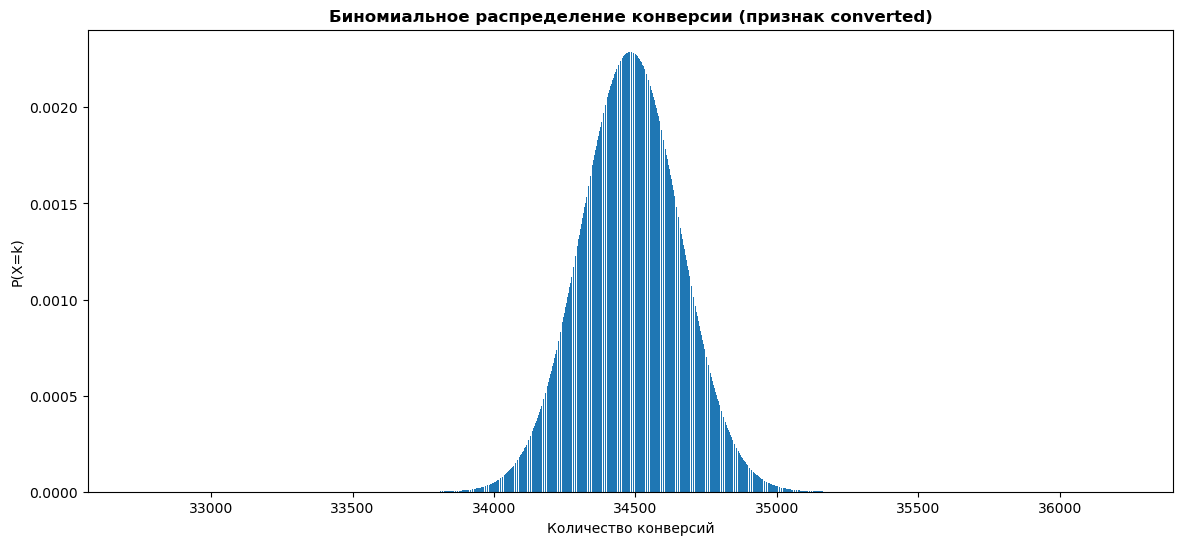

In [59]:
n = len(df)
p = df['converted'].mean()
print('Вероятность: ', p)

bin_convertion_rate = stats.binom(n, p)

# Строк чересчур много (около 300 тысяч), ограничим k для презентабельности графика
E_x = n * p
std = np.sqrt(n * p * (1 - p))
print('Математическое ожидание конверсии: ', E_x, '\nСтандартное отклонение конверсии', std)

k_min = int(max(0, E_x - 10 * std))
k_max = int(min(n, E_x + 10 * std))

k = np.arange(k_min, k_max + 1)
probs = bin_convertion_rate.pmf(k) # pmf - probability mass function (функция вероятности для дискретный распределенений)

plt.figure(figsize=(14, 6)) 
plt.bar(k, probs)
plt.title('Биномиальное распределение конверсии (признак converted)', fontweight='bold')
plt.ylabel('P(X=k)')
plt.xlabel('Количество конверсий')
plt.show()


- <span style="color:skyblue">По интегральной теореме Муавра-Лапласа распределение конверсии можно приблизить нормальным распределением:</span>

$$X \sim \mathcal{N}(np,\ \sqrt{np(1-p)}^2)$$

- <span style="color:skyblue">Проверка перед использованием ИТМЛ:</span>
$$n*p*q ≈ 30255 \ge 25$$


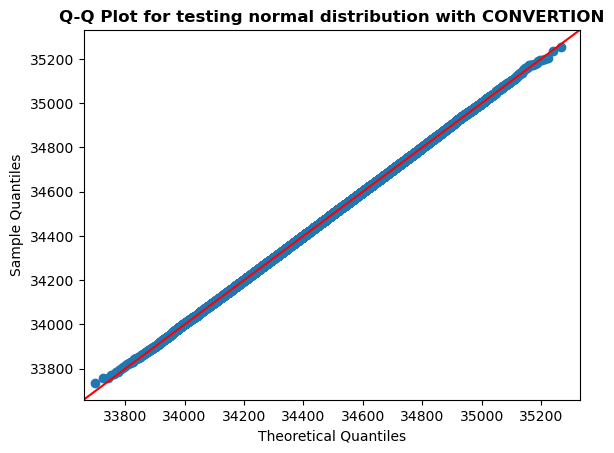

In [60]:
mu = n * p
sigma = np.sqrt(n * p * (1 - p))

sample_size = n
x = stats.binom.rvs(n, p, size=sample_size) # Генерация случ. величин из распределения

fig = sm.qqplot(x, dist=stats.norm, loc=mu, scale=sigma, line='45')
plt.title('Q-Q Plot for testing normal distribution with CONVERTION', fontweight='bold')
plt.show()

- `Подтверждение ИТМЛ, распределение будет действительно приближаться к нормальному (к нашим данным применимо)`

**1. Сравнение выборок через бутстреппинг (средних)**

- <span style="color:skyblue">Для нашей выбранной метрики (converted) определим <u>нулевую гипотезу</u>: CR пользователей после изменения страницы не изменился, тогда <u>альтернативная гипотеза</u>: CR пользователей увеличился с новой страницей (новая страница положительно влияет на регистрацию пользователей на курс)</span>

In [61]:
group_A = np.array(df[df['landing_page'] == 'old_page']['converted'])
group_B = np.array(df[df['landing_page'] == 'new_page']['converted'])

bootstrapping_count = 20000
length_a = len(group_A)
length_b = len(group_B)

np.random.seed(1000)
diff_mean = np.empty(bootstrapping_count)
for i in range(bootstrapping_count):
    boot_a = np.random.choice(group_A, length_a, True)
    boot_b = np.random.choice(group_B, length_b, True)
    diff_mean[i] = boot_b.mean() - boot_a.mean()

confidence_interval = np.percentile(diff_mean, [2.5, 97.5])
print(confidence_interval)

[-0.00395181  0.00077482]


- `Доверительный интервал помогает сделать оценку (диапазон) истинного эффекта: если бутстреп-отрезок содержит значения строго < 0, то можно было бы сказать, что выборка B (группа с новой страницей) демонстрирует хуже результаты по сравнению с выборкой А, в противном случае (строго > 0) B лучше A (группа со старой страницей);`
- `Если 0 (ноль) входит в бутстреп-отрезок, то ожидаемого эффекта с более результативной выборкой не наблюдается, то есть в среднем НЕ обнаруживается значимого различия между выборками.`

<span style="color:skyblue">ПРОМЕЖУТОЧНЫЙ РЕЗУЛЬТАТ:</span>
- `Получаем бутстреп-отрезок (интервал) [-0.00391709, 0.0007957], где 0 входит в диапазон (*), значит, ничего сказать НЕ МОЖЕМ о преимуществах одной группы по результативности над другой группой (контрольная и экспериментальная группы в среднем демонстрируют схожие результаты конверсии)`

<span style="color:yellow">(*):</span> Если 0 входит в интервал, то в среднем в интервал (бутстреп-отрезок) может попадать и нулевая разница выборок (то есть их сходство), поэтому о преимуществах одной выборки над другой ничего говорить не можем

-------------------------
<span style="color:white">ДОПОЛНИТЕЛЬНАЯ ЧАСТЬ:</span>

<span style="color:skyblue">Далее посмотрим на различия с учетом времени и проведем другие статистические тесты, чтобы опровергуть или подтвердить гипотезу о неразличимости контрольной и экспериментальной групп</span>

**1. Сравним временные ряды выполненных целевых действий (converted=1) двух выборок на страницах old page и new page, то есть с учетом времени ДО И ПОСЛЕ ИЗМЕНЕНЕНИЙ**

In [62]:
df_sorted = df.copy()
df_sorted = df.sort_values(by='timestamp', ascending=True)
df_sorted.index = pd.PeriodIndex(df_sorted.timestamp, freq='H')
df_sorted = df_sorted.drop(columns='timestamp')

# Делим на 2 группы: пользователи, которым показывали старую и новую страницы
old_page = df_sorted[df_sorted['landing_page'] == 'old_page']
new_page = df_sorted[df_sorted['landing_page'] == 'new_page']

# Считаем совершенные действия  двух выборках
old_time_series = old_page.groupby('timestamp')['converted'].sum()
new_time_series = new_page.groupby('timestamp')['converted'].sum()

same_length = (len(old_time_series) == len(new_time_series))
print('Размеры выборок совпададают: ', same_length)

old_period = old_time_series.index
new_period = new_time_series.index
same_period = (old_period == new_period)
print('\nДаты совпадают в выборках:\n', same_period)

Размеры выборок совпададают:  True

Даты совпадают в выборках:
 [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True

/var/folders/j_/rgb0xpmj2t1fvbsr_dgr37x80000gn/T/ipykernel_9953/3263522478.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_sorted.index = pd.PeriodIndex(df_sorted.timestamp, freq='H')


In [63]:
old_period = old_period.to_timestamp()
new_period = new_period.to_timestamp()

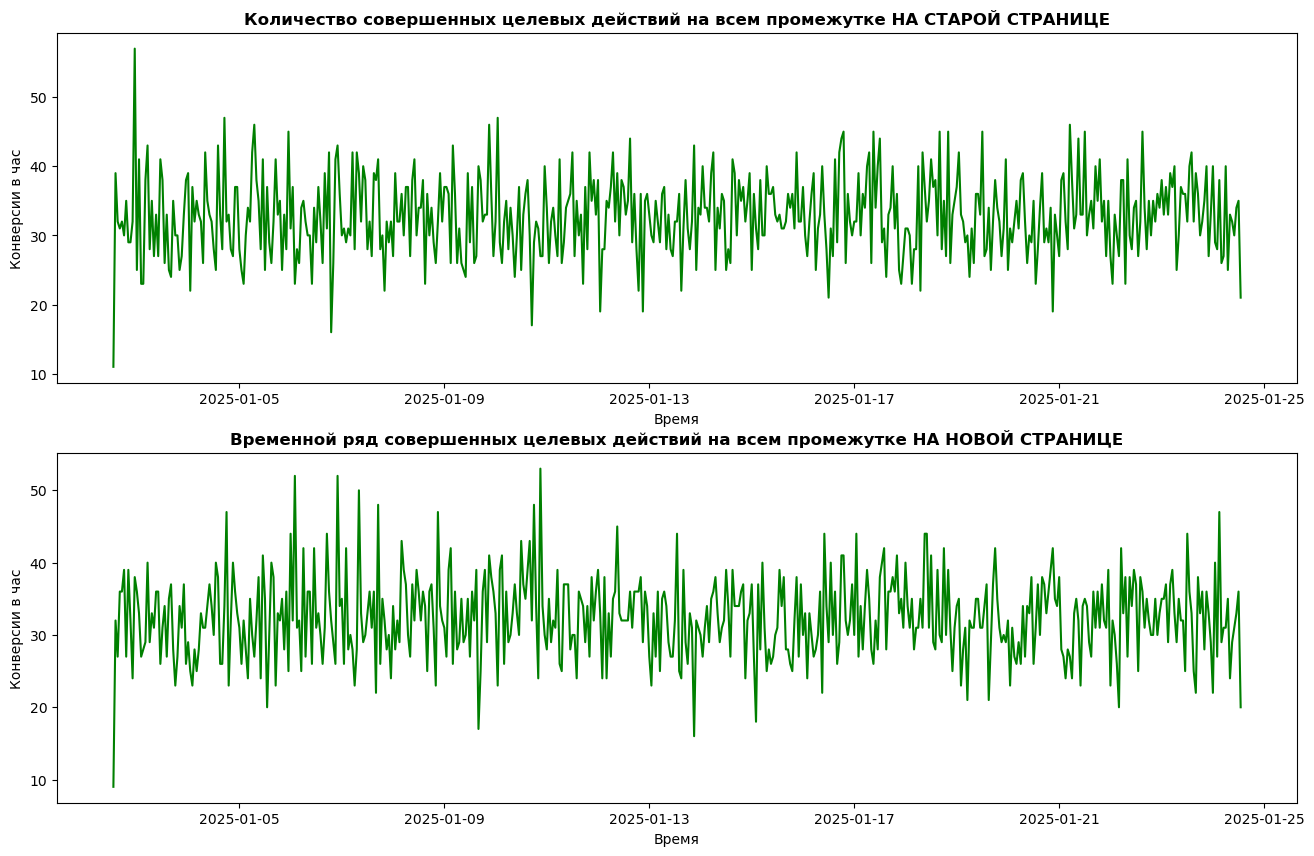

In [64]:
# Визуализируем поведение конверсий экспериментальной и контрольной групп с учетом времени
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

axes[0].plot(old_period, old_time_series.values, color='green')
axes[0].set_title('Количество совершенных целевых действий на всем промежутке НА СТАРОЙ СТРАНИЦЕ', fontweight='bold')
axes[0].set_xlabel('Время')
axes[0].set_ylabel('Конверсии в час')

axes[1].plot(new_period, new_time_series.values, color='green')
axes[1].set_title('Временной ряд совершенных целевых действий на всем промежутке НА НОВОЙ СТРАНИЦЕ', fontweight='bold')
axes[1].set_xlabel('Время')
axes[1].set_ylabel('Конверсии в час')

plt.show()

- `Временные ряды двух выборок однородны, поскольку мат.ожидание и дисперсия постоянны, при этом есть некоторая сезонность, проявляющаяся в увеличенном разбросе дисперсии с начала переиода и в начале каждого временного отрезка`
- `Ниже проверим стационарность`

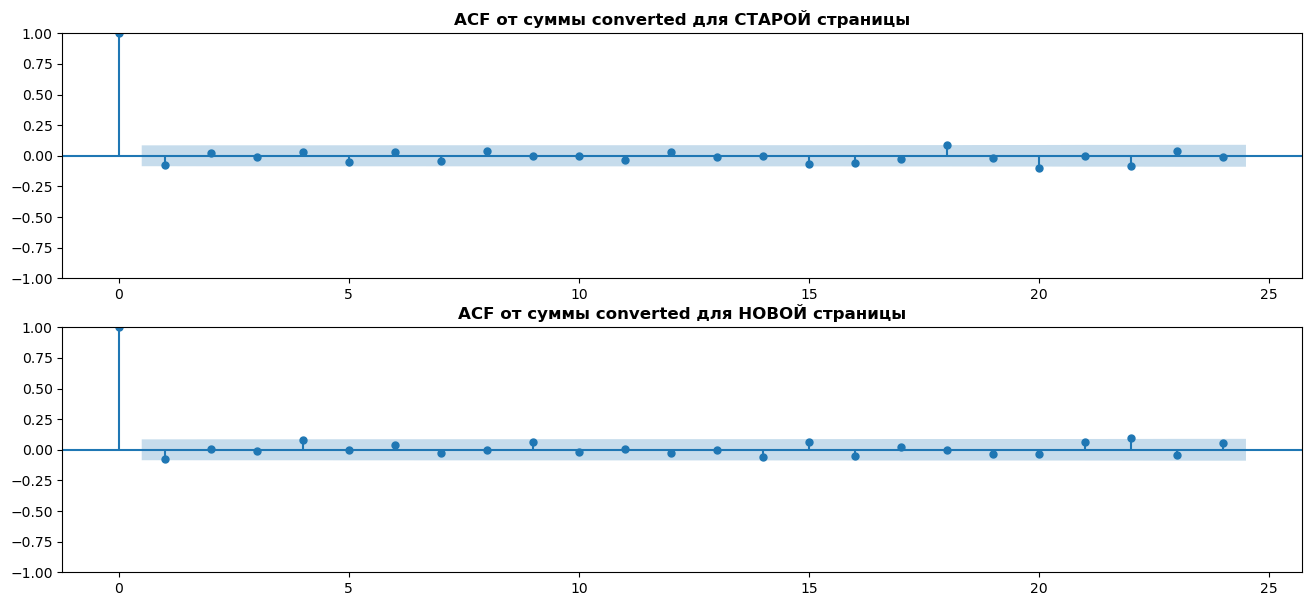

In [65]:
# Автокорреляционная функция
fig, axes = plt.subplots(2, 1, figsize=(16, 7))

x_old = np.asarray(old_time_series).squeeze()
x_new = np.asarray(new_time_series).squeeze()

plot_acf(x_old, lags=24, ax=axes[0])
axes[0].set_title('ACF от суммы converted для СТАРОЙ страницы', fontweight='bold')

plot_acf(x_new, lags=24, ax=axes[1])
axes[1].set_title('ACF от суммы converted для НОВОЙ страницы', fontweight='bold')

plt.show()


- `Временные ряды двух выборок стационарны по результатам ACF-тест`

<span style="color:skyblue">С течением времени конверсия(=1) в контрольной и экспериментальной группах ведет себя практически неразличимо, поэтому далее используем стат. тесты для оценки выборок с точки зрения статистической различимости</span>

**2. Проведем дополнительный анализ двух групп**

**(1) t-критерий Стьюдента:**

<u>Нулевая гипотеза:</u> средняя конверсия в контрольной группе и тестовой группах одинаковые, <u>альтернативная гипотеза</u>: средняя конверсия в тестовой и контрольной группах различаются.

Условия применимости выполняются: 
- выборки являются НЕСВЯЗНЫМИ, так как метрика замеряется у разных объектов (в группах control и treatment)
- распределение приближается к нормальному (через ИТМЛ)

Следовательно, осталось проверить 2 выборки на гомогенность дисперсий через критерий Левена для использования t-критерия

**Критерий Левена:**

<u>Нулевая гипотеза:</u> дисперсии в группах примерно одинаковые, <u>альтернативная гипотеза</u>: дисперсии контрольной и экспериментальной групп различны (негомогенны).

In [66]:
gr_cntr = df[df['group'] == 'control']['converted']
gr_tr = df[df['group'] == 'treatment']['converted']

lev_stat, lev_p = levene(gr_tr, gr_cntr)  
t_stat, p_value = ttest_ind(gr_tr, gr_cntr)

print('Статистика Левена: ', lev_stat)
print('p-value:', lev_p)

Статистика Левена:  1.7303750545387557
p-value: 0.18836405180562277


- `При использовании критерия Левена получили pvalue = 0.188 > 0.05 -> принимаем нулевую гипотезу о равном разбросе дисперсий, то есть дисперсии гомогенны, можем применять t-test`

**t-критерий (гипотезы указаны в начале блока):**

In [67]:
print('t-статистика: ', t_stat)
print('p-value: ', p_value)

t-статистика:  -1.3154372104128556
p-value:  0.18836405180368498


- `При использовании t-test'а получили pvalue = 0.188 > 0.05 -> принимаем нулевую гипотезу об одинаковой средней конверсии в контрольной и тестовой группах`

<span style="color:skyblue">ИТОГ:</span>
t-test не показал статистически значимых различий между контрольной и экспериментальной группами

**(2) Для этих же гипотез и выборок используем z-test пропорций**
- Можем его использовать, так как выборки независимы и количество успехов и неудач достаточно большое

### Как рассчитывается z-критерий (с учетом пропорций):
Считаем выборочные CTR (${x_1}$ и ${x_2}$ - actions в двух выборках соответственно, а ${n_1}$ и ${n_2}$ - views):
$$\hat{p}_1 = \frac{x_1}{n_1}, \qquad \hat{p}_2 = \frac{x_2}{n_2}$$

Используется для оценки стандартной ошибки под $H_0$:
$$\hat{p} = \frac{x_1 + x_2}{n_1 + n_2}$$

Измеряем разницу между $\hat{p}_1$ и $\hat{p}_2$ в единицах стандартной ошибки:
$$z = \frac{\hat{p}_1 - \hat{p}_2}{\sqrt{\hat{p}(1 - \hat{p})\left(\frac{1}{n_1} + \frac{1}{n_2}\right)}}$$

$P-value$ определяет вероятность ошибки, если мы отвергнем $H_0$, и вычисляется с использованием $\Phi$ — функции распределения стандартного нормального закона:
$$p\text{-value} = 2 \cdot \bigl(1 - \Phi(|z|)\bigr)$$

In [68]:
suc_c, k_c = int(gr_cntr.sum()), len(gr_cntr)
suc_t, k_t = int(gr_tr.sum()), len(gr_tr)

z_stat, p_value = proportions_ztest(count=np.array([suc_t, suc_c]), nobs=np.array([k_t, k_c]) , alternative='two-sided')

print('z-статистика: ', z_stat)
print('p-value: ', p_value)

z-статистика:  -1.3154378249176042
p-value:  0.1883628003092841


- `При использовании z-test получили pvalue = 0.188 > 0.05 -> принимаем нулевую гипотезу об одинаковой конверсии в контрольной и тестовой группах`

<span style="color:skyblue">ИТОГ:</span>
z-test не показал статистически значимых различий между контрольной и экспериментальной группами

**(3): Пермутационный тест**

<u>Нулевая гипотеза:</u> конверсии в выборках не различаются

<u>Альтернативная гипотеза:</u> конверсии в выборках различимы

In [69]:
def permutation_test(x, y, r=5000, alternative="two-sided", seed=100):
    random_numbers = np.random.default_rng(seed)
    
    control = np.asarray(x)
    treatment = np.asarray(y)
    n_t = len(treatment)

    mn_diff = treatment.mean() - control.mean()
    joined = np.concatenate([control, treatment])

    n = len(joined)
    indexes = np.arange(n)

    diff_in_perm = np.empty(r)
    for i in range(r):
        treat_idx = random_numbers.choice(indexes, size=n_t, replace=False) # Рандомно выбираем n_t индексов из индексов всей выборки
        mask = np.zeros(n, dtype=bool)
        mask[treat_idx] = True
        diff_in_perm[i] = joined[mask].mean() - joined[~mask].mean()

    if alternative == 'greater': # H_1: p(treatment) > p(control)
        p_value = (1 + np.sum(diff_in_perm >= mn_diff)) / (r + 1)
    elif alternative == 'less': # H_1: p(treatment) < p(control)
        p_value = (1 + np.sum(diff_in_perm <= mn_diff)) / (r + 1)
    else:
        p_value = (1 + np.sum(np.abs(diff_in_perm) >= abs(mn_diff))) / (r + 1)

    return mn_diff, p_value

e_x_mean, p_value = permutation_test(gr_cntr, gr_tr, r=5000, alternative='greater') # Нас интересует то, где конверсия в экспериментальной группе выше, чем в контрольной
print('Разница средних: ', e_x_mean, 'p-value: ', p_value)

Разница средних:  -0.0015885279397493263 p-value:  0.9052189562087583


<span style="color:yellow">ОБЩИЙ ВЫВОД:</span>
- Экспериментальная и контрольная группы статистически неразличимы по результатам 4 тестов (бутстреппинг мат. ожиданий, z-test, t-test и пермутационного теста)
- Пермутационный тест подтвердил результаты всех предыдущих тестов
- **Новая страница статистически лучше не влияет на поведение пользователя по сравнению со старой страницей**